In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 80)

df = pd.read_csv('data/survey.csv')
df.shape

(5000, 16)

### 1. Exploring data

In [183]:
# What features are there, what does the data look like, etc.
df.head(3)

,ResponseId,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,Industry,Country,Currency,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,annual_salary_usd
0,1,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,Fintech,Ukraine,EUR European Euro,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,61256.0
1,10004,55-64 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,40.0,46.0,"Developer, full-stack","10,000 or more employees",Individual contributor,"Your choice (very flexible, you can come in wh...",Computer Systems Design and Services,Germany,EUR European Euro,C#;Java;SQL,H2;MariaDB;Neo4J;Oracle,99773.0
2,10016,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,2.0,5.0,"Developer, full-stack","10,000 or more employees",Individual contributor,Remote,Healthcare,United States of America,USD United States dollar,Bash/Shell (all shells);C#;HTML/CSS;JavaScript...,Microsoft SQL Server;MongoDB,85000.0


In [184]:
# Looking at data types, nulls, unique values count
print("total length: ", len(df))
pd.DataFrame({
    'dtype':  df.dtypes,
    'nulls':  df.isna().sum(),
    'null%': (df.isna().mean() * 100).round(1),
    'unique': df.nunique(),
})

total length:  5000


,dtype,nulls,null%,unique
ResponseId,int64,0,0.0,5000
Age,object,0,0.0,7
EdLevel,object,5,0.1,8
Employment,object,0,0.0,6
WorkExp,float64,52,1.0,54
YearsCode,float64,21,0.4,57
DevType,object,0,0.0,32
OrgSize,object,530,10.6,9
ICorPM,object,602,12.0,2
RemoteWork,object,553,11.1,5


### What the columns mean

| Column | Meaning |
|---|---|
| `ResponseId` | Survey row ID — no signal |
| `Age` | Age bracket |
| `EdLevel` | Highest education completed |
| `Employment` | Employed / freelance / student / not employed / retired |
| `WorkExp` | Years of professional experience |
| `YearsCode` | Years coding at all, incl. hobby — starts earlier, so runs higher |
| `DevType` | Job role (32 values) |
| `OrgSize` | Employer headcount bracket |
| `ICorPM` | Individual contributor vs. people manager |
| `RemoteWork` | Remote / hybrid / in-person |
| `Industry` | Employer sector (15 values) |
| `Country` | Country of residence (130 values) |
| `Currency` | Currency pay was reported in |
| `LanguageHaveWorkedWith` | Languages used in past year, `;`-separated |
| `DatabaseHaveWorkedWith` | Databases used in past year, `;`-separated |
| `annual_salary_usd` | **Target** — annual pay converted to USD |

Immediate takeaways:
- Most columns are text, need to do encoding
- This is a FORM:
    - Some questions are optional (null fields): edlevel, workexp (people can be unemployed), etc.
    - There are conditional sections
- Language have worked with/db have worked with have a lot of unique values, they are not categories

In [185]:
print("duplicate rows:", df.duplicated().sum())
print("duplicate response ids:", df.ResponseId.duplicated().sum())

duplicate rows: 0
duplicate response ids: 0


### 2. The target: `annual_salary_usd`

In [186]:
# Looking for null rows, descriptive stats, percentiles
s = df['annual_salary_usd']
print('missing:', s.isna().sum())
print(s.describe().round(0))
s.quantile([0, .001, .01, .05, .25, .5, .75, .95, .99, .999, 1]).round(0)

missing: 84
count       4916.0
mean       98353.0
std       145434.0
min            1.0
25%        41765.0
50%        77559.0
75%       123993.0
max      6890299.0
Name: annual_salary_usd, dtype: float64


0.000          1.0
0.001          3.0
0.010         86.0
0.050       3988.0
0.250      41765.0
0.500      77559.0
0.750     123993.0
0.950     232029.0
0.990     500000.0
0.999    1291669.0
1.000    6890299.0
Name: annual_salary_usd, dtype: float64

We note here:
- Some rows have null target values
- Most salaries fall under 500k (99%)
- The interquartile range is between 41765.0 and 123993.0 (some major outliers, both small and big)

In [187]:
# Lowest salaries (trolls?)
df.nsmallest(5, 'annual_salary_usd')[['Country', 'Currency', 'Employment', 'WorkExp', 'annual_salary_usd']]

,Country,Currency,Employment,WorkExp,annual_salary_usd
306,Indonesia,IDR\tIndonesian rupiah,Employed,5.0,1.0
2192,Colombia,COP\tColombian peso,"Independent contractor, freelancer, or self-em...",1.0,1.0
2842,China,CNY\tChinese Yuan Renminbi,Employed,8.0,1.0
3766,Bangladesh,USD United States dollar,Employed,16.0,2.0
3142,Taiwan,TWD New Taiwan dollar,Employed,8.0,3.0


In [188]:
# Some of the highest salaries
df.nlargest(5, 'annual_salary_usd')[['Country', 'Currency', 'Employment', 'WorkExp', 'annual_salary_usd']]

,Country,Currency,Employment,WorkExp,annual_salary_usd
3236,Ukraine,UAH Ukrainian hryvnia,"Independent contractor, freelancer, or self-em...",15.0,6890299.0
1858,India,USD United States dollar,Employed,6.0,2500000.0
2896,United States of America,USD United States dollar,Employed,15.0,2000000.0
4493,United States of America,USD United States dollar,Employed,11.0,1950000.0
3294,Finland,EUR European Euro,Employed,20.0,1740220.0


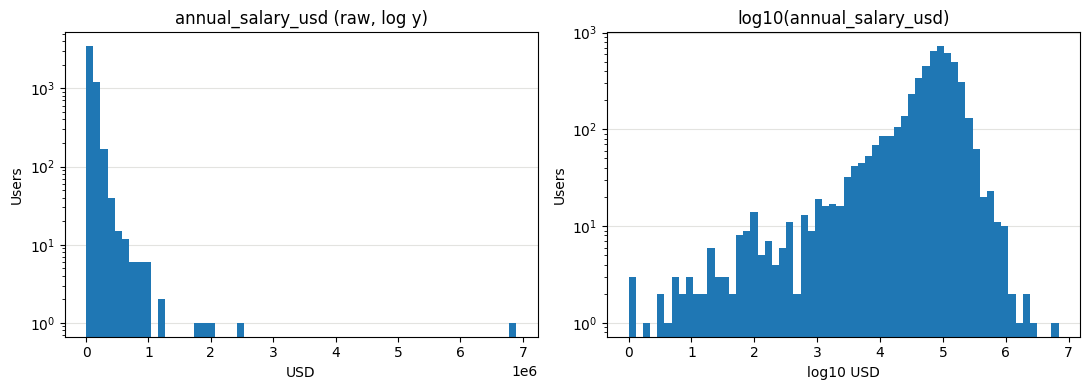

In [189]:
# Plotting histogram
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw salary vs. number of users
axes[0].hist(s.dropna(), bins=60)
axes[0].set_yscale('log')
axes[0].set_title('annual_salary_usd (raw, log y)')
axes[0].set_xlabel('USD')

# Logged salary vs. number of users
log_s = np.log10(s[s > 0])
axes[1].hist(log_s, bins=60)
axes[1].set_yscale('log')
axes[1].set_title('log10(annual_salary_usd)')
axes[1].set_xlabel('log10 USD')

for ax in axes:
    ax.set_ylabel('Users')
    ax.grid(axis='y', color='#E3E3E0', linewidth=0.8)
    ax.set_axisbelow(True) # put lines in background
plt.tight_layout()

There is a long right tail on the left histogram, indicating significant right skew.
- This somewhat makes sense, since this is salary data (there's minimum wage, but there's also a less bounded ceiling for high earners)
- Logging the number of users will help with this, see right histogram

There are probably also a lot of liars, so we will trim everything outside of the bounds $504-$3M.
    
- $504 is the lowest minimum wage of the participating countries, [Nigeria](https://employsome.com/blog/minimum-wage-nigeria/)
- $3M is 3x the highest recorded salary on [levels.fyi](https://www.levels.fyi/leaderboard/Software-Engineer/Entry-Level-Engineer/country/United-States/) (~$1M)

Results of applying these changes are as follows:

In [190]:
s = s[s > 0] # drop all rows w/ no target value
cleaned_s = s[(s > 504) & (s < 3e6)] # trim bounds
cleaned_s = np.log10(cleaned_s) # log target

print("raw salaries skew: ", stats.skew(s))
print("cleaned salaries skew:", stats.skew(cleaned_s))

raw salaries skew:  23.839067699686105
cleaned salaries skew: -1.3434563009351552


## 3. Data features

### 3.1 Country & Currency

In [191]:
print('countries:', df.Country.nunique())
print('countries with <100 rows:', (df.Country.value_counts() < 100).sum())
df.Country.value_counts().head(20)

countries: 130
countries with <100 rows: 117


Country
United States of America                                1089
Germany                                                  441
United Kingdom of Great Britain and Northern Ireland     316
India                                                    262
France                                                   223
Canada                                                   175
Ukraine                                                  161
Brazil                                                   132
Italy                                                    130
Netherlands                                              127
Poland                                                   121
Australia                                                119
Spain                                                    114
Sweden                                                    96
Switzerland                                               78
Czech Republic                                            68
Hungary         

There are 130 countries, but we see that only the top 13 countries have >100 responses.
- Instead of adding 130 one-hot encoding columns, we can just take the top 15, and group everything else into "other" (Sweden and Switzerland are close enough)
- The other countries are rare and have a sample size that is too restrictive, which could lead to overfitting

### 3.2 Employment

In [192]:
df.Employment.value_counts()

Employment
Employed                                                4215
Independent contractor, freelancer, or self-employed     589
Not employed                                              90
Student                                                   85
I prefer not to say                                       11
Retired                                                   10
Name: count, dtype: int64

Since "I prefer not to say" is too vague and everything else implies that they are unemployed, we can remove all rows except for the ones that are "employed" or "freelancer". These two also happen to be the majority classes.

### 3.3 WorkExp and YearsCode

In [193]:
corr = df[['WorkExp', 'YearsCode']].corr()
print('\ncorrelation:', corr.iloc[0, 1].round(3))


correlation: 0.889


Correlation is quite high; these two columns represent roughly the same thing, so we can get rid of YearsCode later.

In [194]:
#  looking for unrealistic values
print(df[['WorkExp', 'YearsCode']].describe().round(1))
print('rows at upper bound:', ((df.WorkExp >= 50)).sum())
print('rows at lower bound:', ((df.WorkExp <= 0)).sum())

       WorkExp  YearsCode
count   4948.0     4979.0
mean      13.1       17.7
std        9.7       10.5
min        1.0        1.0
25%        6.0       10.0
50%       11.0       15.0
75%       18.0       25.0
max      100.0      100.0
rows at upper bound: 10
rows at lower bound: 0


Most people work for 40-45 years before they retire. ~50 seems like a reasonable estimate for an upper bound, so we will remove all rows greater than this.

In [195]:
# null columns
print('null values: ', df.WorkExp.isna().sum())

# checking if this a conditional field (unemployed people shouldn't have to fill this out)
rate = pd.crosstab(df.Employment, df.WorkExp.isna(), normalize='index')[True]
print('WorkExp blank rate by Employment (%):')
print(rate.mul(100).round(1).sort_values(ascending=True))

null values:  52
WorkExp blank rate by Employment (%):
Employment
Retired                                                  0.0
Independent contractor, freelancer, or self-employed     0.2
Employed                                                 0.8
Not employed                                             1.1
Student                                                 17.6
I prefer not to say                                     27.3
Name: True, dtype: float64


There are some null values this is a conditional field; unemployed people left this blank. Since we remove these rows from the previous section, this should be fine. We deal with null values in our choice of model (explained below).

### 3.4 Age, EdLevel, OrgSize

In [196]:
for col in ['Age', 'EdLevel', 'OrgSize']:
    print(df[col].value_counts(dropna=False), '\n')

Age
25-34 years old      1892
35-44 years old      1578
45-54 years old       664
18-24 years old       545
55-64 years old       270
65 years or older      45
Prefer not to say       6
Name: count, dtype: int64 

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          2283
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       1464
Some college/university study without earning a degree                                 578
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         242
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     212
Associate degree (A.A., A.S., etc.)                                                    150
Other (please specify):                                                                 48
Primary/elementary school                                                               18
NaN                                               

These look like multiple choice questions. Since they are all ordinal data, we will use integer encoding.
- For EdLevel, we can just to 1-7 and fill null values with the median
- OrgSize also has some null values. We will use add_indicator here, since we can't just take the median in all cases (could be a freelancer)
- For the others, we use the midpoint value of each option to convey differences between options
- EdLevel may be correlated with age/working experience and vice versa. We might have to do something about this, but it will depend on the type of model we pick

### 3.5 Language and DB have worked with

In [197]:
langs = df.LanguageHaveWorkedWith.dropna().str.split(';').explode()
print('distinct languages:', langs.nunique())
langs.value_counts().head(20)

distinct languages: 42


LanguageHaveWorkedWith
JavaScript                 3213
HTML/CSS                   2957
SQL                        2895
Python                     2621
TypeScript                 2329
Bash/Shell (all shells)    2270
C#                         1382
Java                       1372
PowerShell                 1088
C++                         968
Go                          856
PHP                         838
C                           824
Rust                        700
Kotlin                      532
Lua                         378
Ruby                        320
Groovy                      244
Assembly                    239
Swift                       237
Name: count, dtype: int64

In [198]:
dbs = df.DatabaseHaveWorkedWith.dropna().str.split(';').explode()
print('distinct dbs:', dbs.nunique())
dbs.value_counts().head(10)

distinct dbs: 30


DatabaseHaveWorkedWith
PostgreSQL              2371
MySQL                   1577
SQLite                  1483
Redis                   1300
Microsoft SQL Server    1259
MongoDB                  926
MariaDB                  836
Elasticsearch            777
Dynamodb                 439
Oracle                   400
Name: count, dtype: int64

A user can know multiple dbs/multiple languagse, so this is a "select all that apply" type input. We can use multi-hot encoding here for both.
- I want to avoid lumping rarer languages/dbs into an "other" column here, since a rare language (e.g. COBOL) could mean high pay or that the language is obsolete/no longer in demand

### 3.7 DevType, RemoteWork, ICorPM, ResponseId

In [199]:
for col in ['DevType', 'RemoteWork', 'ICorPM']:
    print(f'{col} ({df[col].nunique()} values):')
    print(df[col].value_counts(dropna=False).head(10), '\n')

DevType (32 values):
DevType
Developer, full-stack                            1790
Developer, back-end                               932
Architect, software or solutions                  356
Developer, front-end                              253
Developer, desktop or enterprise applications     251
Developer, mobile                                 192
Developer, embedded applications or devices       182
DevOps engineer or professional                   134
Engineering manager                               121
AI/ML engineer                                     97
Name: count, dtype: int64 

RemoteWork (5 values):
RemoteWork
Remote                                                                          1554
Hybrid (some remote, leans heavy to in-person)                                   894
Hybrid (some in-person, leans heavy to flexibility)                              819
In-person                                                                        613
Your choice (very flexible, y

- Drop ResponseId, it's useless
- One-hot remaining three, none of these are ordinal
- DevType: Same approach as Country for DevType; keep the top 12 roles and group the rest into "Other" to prevent overfitting on rows with too few samples
- RemoteWork: keep all 5 levels, fill in blanks with "missing" label since it could mean it doesn't apply

## 4. Cleaning

In [200]:
clean = df.copy()

# Remove rows with no target
clean = clean[clean.annual_salary_usd.notna()]

# Remove unrealistic salaries
clean = clean[clean.annual_salary_usd.between(504, 3_000_000)]

# Remove unemployed people
clean = clean[clean.Employment.isin([
    'Employed',
    'Independent contractor, freelancer, or self-employed',
])]

# Remove people with more than 50 years of working experience
clean = clean[clean.WorkExp.isna() | (clean.WorkExp <= 50)]

# Integer label encoding
ED_RANK = {
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 4,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 5,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 7,
}
# Midpoints for org size and age
ORG_MID = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    'Less than 20 employees': 10,       '20 to 99 employees': 50,
    '100 to 499 employees': 300,        '500 to 999 employees': 750,
    '1,000 to 4,999 employees': 2_500,  '5,000 to 9,999 employees': 7_500,
    '10,000 or more employees': 20_000,
}
AGE_MID = {
    '18-24 years old': 21, '25-34 years old': 30, '35-44 years old': 40,
    '45-54 years old': 50, '55-64 years old': 60, '65 years or older': 70,
}
clean['ed_rank']  = clean.EdLevel.map(ED_RANK)
clean['org_size'] = clean.OrgSize.map(ORG_MID)
clean['age_mid']  = clean.Age.map(AGE_MID)

print(f'{len(df) - len(clean)} removed')

326 removed


## 5. Building features and train/test split

In [201]:
from sklearn.model_selection import train_test_split

TARGET = 'annual_salary_usd'

# Returns a new column that doesn't touch all rows that are in the top n
# most frequent, and labels everything else as "Other"
def lump(col, n):
    top = col.value_counts().head(n).index # names
    return col.where(col.isin(top), 'Other')

CATEGORICAL = ['country', 'devtype', 'remote', 'icorpm', 'industry', 'employment']
NUMERIC     = ['WorkExp', 'ed_rank', 'org_size', 'age_mid']

feat = pd.DataFrame(index=clean.index)
# Handling categorical data as discussed above
feat['country']    = lump(clean.Country, 15)  
feat['devtype']    = lump(clean.DevType, 12) 
feat['remote']     = clean.RemoteWork.fillna('Missing')
feat['icorpm']     = clean.ICorPM.fillna('Missing')
feat['industry']   = clean.Industry.fillna('Missing')
feat['employment'] = clean.Employment
for col in NUMERIC:
    feat[col] = clean[col]

# Replace null values w/ blank, otherwise split and get 0/1 column per lang/db
langs = clean.LanguageHaveWorkedWith.fillna('').str.get_dummies(';').add_prefix('lang_')
dbs   = clean.DatabaseHaveWorkedWith.fillna('').str.get_dummies(';').add_prefix('db_')
feat['n_languages'] = langs.sum(axis=1)
feat['n_databases'] = dbs.sum(axis=1)

# Put everything together, log target values. One-hot the six categoricals
# here rather than in a ColumnTransformer later: doing it before the split
# means train and test are sliced out of one already-encoded table, so their
# columns line up by construction.
feat = pd.get_dummies(feat, columns=CATEGORICAL, dtype=int)
X = pd.concat([feat, langs, dbs], axis=1)
y = np.log(clean[TARGET])

# 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69)
print(X_train.shape, X_test.shape)

(3739, 134) (935, 134)


In [202]:
X.head(5)

,WorkExp,ed_rank,org_size,age_mid,n_languages,n_databases,country_Australia,country_Brazil,country_Canada,country_France,...,db_MySQL,db_Neo4J,db_Oracle,db_Pocketbase,db_PostgreSQL,db_Redis,db_SQLite,db_Snowflake,db_Supabase,db_Valkey
0,8.0,6.0,50.0,30.0,3,2,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,40.0,6.0,20000.0,60.0,3,4,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
2,2.0,5.0,20000.0,30.0,7,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17.0,6.0,50.0,40.0,5,2,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,20.0,5.0,2500.0,40.0,5,3,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


## 6. Baseline (median)

In [209]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

# y is in log space, so exponentiate back to dollars before scoring -- an MAE
# in log units means nothing to a human, and I want every number in this
# notebook to be readable as "dollars this model was off by".
def report(name, y_true_log, y_pred_log):
    actual, pred = np.exp(y_true_log), np.exp(y_pred_log)
    return {
        'model': name,
        'MAE':   mean_absolute_error(actual, pred),
        'MedAE': median_absolute_error(actual, pred),
        'R2':    r2_score(actual, pred),
    }

# Dollars to the nearest dollar, R2 to 3 dp.
ROUNDING = {'MAE': 0, 'MedAE': 0, 'R2': 3}

baseline_pred = np.full(len(y_test), y_train.median())
baseline_row = report('baseline (median)', y_test, baseline_pred)
pd.DataFrame([baseline_row])

,model,MAE,MedAE,R2
0,baseline (median),59322.80107,38594.0,-0.057509


## 7. Model

I chose ridge and random forest.
- Ridge was chosen as a linear baseline for random forest/to account for correlated features, since linear regression doesn't do that
- Random forest captures non-linear relationships, and are very suitable for tabular data
    - E.g. salary increases non-linearly over time

Params:
- Ridge: we use a standard alpha value of 1 for L2 regularization
- Random forest: since you can't overfit on random forest, we use 300 estimators, 

In [212]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# for the models that can't read NaN, fill with the median AND add
# a 0/1 indicator column, so the model can tell a filled-in value from a real
# one. 
imputer = SimpleImputer(strategy='median', add_indicator=True)

candidates = {
    'ridge': (Ridge(alpha=1.0), True),
    'random forest': (RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1), True),
}

results = [baseline_row]
fitted = {}
for name, (estimator, needs_imputer) in candidates.items():
    steps = []
    if needs_imputer:
        steps.append(('impute', imputer))
    steps.append(('model', estimator))
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results.append(report(name, y_test, pipe.predict(X_test)))

pd.DataFrame(results).round(ROUNDING)

,model,MAE,MedAE,R2
0,baseline (median),59323.0,38594.0,-0.058
1,ridge,44819.0,22432.0,0.224
2,random forest,39896.0,20555.0,0.404


 We can see that both ridge and random forest outperform the median baseline.
 - Random forest wins on all three metrics. MedAE drops from $38,594 to $20,555, so a
  typical prediction is roughly twice as close as guessing the median
  - Random forest beats ridge, most likely since, pay doesn't move linearly, and
    the effect of experience depends on country, which a linear model can't represent
  - MAE is well above above MedAE for every model, which means a small number of rows are
    absorbing most of the error

## Evaluation

In [218]:
model = fitted['random forest']

err = clean.loc[X_test.index, ['Country']].copy()
err['actual']  = np.exp(y_test)
err['pred']    = np.exp(model.predict(X_test))
err['abs_err'] = (err.pred - err.actual).abs()
err['pct_err'] = err.abs_err / err.actual

# Does it collapse on high earners?
print('median error by salary quartile:')
display(err.groupby(pd.qcut(err.actual, 4), observed=True)[['abs_err', 'pct_err']]
           .median().round(2))

median error by salary quartile:


,abs_err,pct_err
actual,,
"(549.999, 47791.0]",11799.32,0.57
"(47791.0, 83531.0]",16912.65,0.26
"(83531.0, 130019.0]",21773.80,0.20
"(130019.0, 1250000.0]",57815.47,0.33


- We see that the model is not equally good across salary levels
  - The model cannot predict high earners. The things that set top-of-market pay (employer, level,
    equity) are not columns in this survey, so the model hedges toward the middle
  - Proportionally though, the bottom quartile is the worst one at 57%, since being $12k off is most
    of the salary. The middle two sit around 20-26%, which is where the model is actually usable

In [219]:
# What is the model actually leaning on? Feature names have to come from the
# whole pipeline except the final step, because the imputer adds columns.
print('top 12 features:')
names = model[:-1].get_feature_names_out()
display(pd.Series(model[-1].feature_importances_, index=names)
          .sort_values(ascending=False).head(12).round(3))

top 12 features:


WorkExp                             0.183
country_United States of America    0.164
org_size                            0.041
n_languages                         0.035
country_India                       0.031
country_Other                       0.028
ed_rank                             0.027
n_databases                         0.027
country_Ukraine                     0.023
age_mid                             0.015
devtype_Developer, full-stack       0.011
country_Brazil                      0.010
dtype: float64

- We see that the model heavily leans on working experience and the user being from the US, which makes sense, since most responses are US-based

### Conclusion

Random forest roughly halves the median error compared to predicting the median, so the model does
find real patterns.
- The error analysis is what says where it can be used: it is reasonable in the
middle of the distribution (around 20% off), too low for high earners, and proportionally worst for
the lowest paid
- Almost all of that signal comes from two columns, experience and country, which is
a limit of this dataset rather than of the model. Predicting an individual's offer would need
employer, level and cost-of-living data that the survey does not contain

### With more time

- Add cost-of-living or PPP data per country. Country is doing most of the work, but raw USD mixes
  up "is paid more" with "lives somewhere expensive", so e.g. a US and an Indian salary are not really the
  same unit
- Score with cross validation instead of a single 80/20 split. One test split is a few hundred rows,
  which is not enough to tell a real gap between two models from a lucky split
- Tune the random forest (max_depth, min_samples_leaf) with GridSearchCV, and look into/try
  gradient boosting